<a href="https://colab.research.google.com/github/3est9/Trabajo-de-I-D-i/blob/main/Trabajo_de_I%2BD%2Bi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo de I+D+i

En esta primera parte obtenemos el tipo de cambio EUR/USD
utilizando la API de Frankfurter y guardamos los datos en un CSV.

In [33]:
import requests
import pandas as pd

url = "https://api.frankfurter.dev/v1/latest?from=EUR"

respuesta = requests.get(url)
datos = respuesta.json()

datos

{'amount': 1.0,
 'base': 'EUR',
 'date': '2026-10-02',
 'rates': {'AUD': 1.6176,
  'BRL': 5.861,
  'CAD': 1.5984,
  'CHF': 0.9279,
  'CNY': 7.5259,
  'CZK': 24.47,
  'DKK': 7.4736,
  'GBP': 0.85033,
  'HKD': 8.8084,
  'HUF': 369.18,
  'IDR': 20149.32,
  'ILS': 3.4408,
  'INR': 108.1245,
  'ISK': 137.0,
  'JPY': 176.99,
  'KRW': 1513.44,
  'MXN': 20.5806,
  'MYR': 4.5849,
  'NOK': 10.8315,
  'NZD': 2.0002,
  'PHP': 70.265,
  'PLN': 4.3775,
  'RON': 5.3488,
  'SEK': 11.29,
  'SGD': 1.4366,
  'THB': 37.71,
  'TRY': 55.165,
  'USD': 1.1225,
  'ZAR': 18.7839}}

In [32]:
fecha = datos["date"]
cambios = datos["rates"]

df = pd.DataFrame([cambios])
df.insert(0, "Fecha", fecha)

df

,Fecha,AUD,BRL,CAD,CHF,CNY,CZK,DKK,GBP,HKD,...,NZD,PHP,PLN,RON,SEK,SGD,THB,TRY,USD,ZAR
0,2026-10-02,1.6176,5.861,1.5984,0.9279,7.5259,24.47,7.4736,0.85033,8.8084,...,2.0002,70.265,4.3775,5.3488,11.29,1.4366,37.71,55.165,1.1225,18.7839


In [31]:
df.to_csv("tipos_cambio.csv", index=False)

print("CSV creado correctamente")

CSV creado correctamente


In [34]:
url_csv = "https://raw.githubusercontent.com/3est9/Trabajo-de-I-D-i/refs/heads/main/tipos_cambio.csv"
df_csv = pd.read_csv(url_csv)

df_csv.describe()

,AUD,BRL,CAD,CHF,CNY,CZK,DKK,GBP,HKD,HUF,...,NZD,PHP,PLN,RON,SEK,SGD,THB,TRY,USD,ZAR
count,1.0000,1.000,1.0000,1.0000,1.0000,1.00,1.0000,1.00000,1.0000,1.00,...,1.0000,1.000,1.0000,1.0000,1.00,1.0000,1.00,1.000,1.0000,1.0000
mean,1.6176,5.861,1.5984,0.9279,7.5259,24.47,7.4736,0.85033,8.8084,369.18,...,2.0002,70.265,4.3775,5.3488,11.29,1.4366,37.71,55.165,1.1225,18.7839
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.6176,5.861,1.5984,0.9279,7.5259,24.47,7.4736,0.85033,8.8084,369.18,...,2.0002,70.265,4.3775,5.3488,11.29,1.4366,37.71,55.165,1.1225,18.7839
25%,1.6176,5.861,1.5984,0.9279,7.5259,24.47,7.4736,0.85033,8.8084,369.18,...,2.0002,70.265,4.3775,5.3488,11.29,1.4366,37.71,55.165,1.1225,18.7839
50%,1.6176,5.861,1.5984,0.9279,7.5259,24.47,7.4736,0.85033,8.8084,369.18,...,2.0002,70.265,4.3775,5.3488,11.29,1.4366,37.71,55.165,1.1225,18.7839
75%,1.6176,5.861,1.5984,0.9279,7.5259,24.47,7.4736,0.85033,8.8084,369.18,...,2.0002,70.265,4.3775,5.3488,11.29,1.4366,37.71,55.165,1.1225,18.7839
max,1.6176,5.861,1.5984,0.9279,7.5259,24.47,7.4736,0.85033,8.8084,369.18,...,2.0002,70.265,4.3775,5.3488,11.29,1.4366,37.71,55.165,1.1225,18.7839


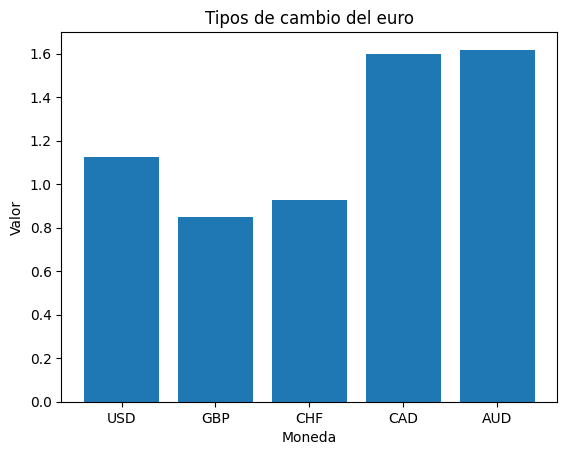

In [35]:
import matplotlib.pyplot as plt

monedas = ["USD", "GBP", "CHF", "CAD", "AUD"]
valores = [df_csv[moneda].iloc[0] for moneda in monedas]

plt.bar(monedas, valores)
plt.title("Tipos de cambio del euro")
plt.xlabel("Moneda")
plt.ylabel("Valor")
plt.show()